# U2_T3A · Forma anidada de Horner, derivadas y deflación

### Evaluación eficiente de polinomios

## ¿Qué vas a aprender?

Evaluar un polinomio «como está escrito» es un desperdicio: calcular
$x^{4}$, $x^{3}$, $x^{2}$ por separado repite trabajo y **arrastra el error de redondeo de cada potencia**. La **regla de Horner** reescribe el polinomio de forma
anidada y consigue el mismo resultado con $n$ multiplicaciones en lugar de
$O(n^2)$.

De paso, esa misma pasada te regala **tres cosas más**: la derivada $P\,'(x_0)$
(con una segunda corrida) y el **polinomio deflactado** $Q(x)$ de dividir entre
$(x-x_0)$.

| # | Pregunta | Tipo | Puntos |
|---|---|---|---|
| 1 | Cuánto ahorra la forma anidada | opción múltiple | 10 |
| 2 | Programar `horner(a, x0)` | código (casos ocultos) | 25 |
| 3 | Valor $P(x_0)$ de tu ejercicio | numérica | 15 |
| 4 | Derivada $P\,'(x_0)$ de tu ejercicio | numérica | 15 |
| 5 | Deflación: coeficientes de $Q(x)$ | 3 casillas | 25 |
| 6 | Decisión de ingeniería | opción múltiple | 10 |

$$\text{Calificación} = 0.70\,(\text{automático}) + 0.30\,(\text{2 actividades a mano})$$

Se requiere **$\ge 90\%$** de los 100 puntos automáticos para poder enviar.

> **Importante:** la tarea está **sembrada con tu número de control**. Cada
> compañero tiene polinomios, puntos de evaluación y raíces distintos. Copiar
> no sirve: la función se califica con **casos ocultos** que nunca ves.

---

## Cómo usar este cuaderno

1. Escribe tu correo institucional en la celda de identificación.
2. Lee la teoría de las secciones 1 y 2 (son cortas y traen un laboratorio).
3. Haz la **actividad a mano** de la sección 3 **con calculadora** y reporta
   tus valores.
4. Programa `horner` y compruébala con **tu** ejercicio.
5. Repite con la **deflación** en la sección 4.
6. Al final, imprime la **hoja de trabajo manual** y envíala junto con tu
   cuaderno.

> 🧰 **Herramientas de visualización.** En `tools/visualizar.py` están —a la
> vista y sin nada ofuscado— las funciones con las que los laboratorios
> imprimen sus tablas y gráficas: `tabla_experimento(...)`,
> `graficar_polinomio(...)`, `graficar_errores(...)` y `latex_cientifico(...)`.
> La celda de configuración ya las carga, así que puedes usarlas en tus propios
> cuadernos (o `import visualizar` si prefieres escribirlas con su nombre
> completo).


In [1]:
#@title ⚙️ Configuración general — ejecuta esta celda **PRIMERO** (no modificar)
# ============================================================
# CELDA 1 — CONFIGURACIÓN GENERAL
# Detecta si corre en Google Colab o en tu computadora, monta Drive y
# carga el motor de la tarea:
#     Colab    -> grader_ofuscado.txt  (lo que ve el alumno)
#     PC local -> grader_local.py      (el MISMO motor, legible, para depurar)
# Los dos archivos los genera  python tools/build.py  a partir de las
# mismas fuentes: el código es idéntico, solo cambia la presentación.
# ============================================================
import base64
import importlib
import os
import subprocess
import sys
import zlib

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4.5)

# ¿Estamos en Google Colab?
try:
    import google.colab
    ES_COLAB = True
except ImportError:
    ES_COLAB = False

# --- Repositorio de la tarea  <-- EDITAR SOLO SI CAMBIA EL REPO ------
REPO_URL = "https://github.com/ITH-MGL-MN/U2_T3A.git"
REPO_NOMBRE = "U2_T3A"

# --- Solo en tu computadora: qué versión del motor quieres probar ---
#   True  -> grader_local.py     (bundle legible, se puede leer y depurar)
#   False -> grader_ofuscado.txt (exactamente lo que recibe el alumno)
DEBUG_SIN_OFUSCAR = True

if ES_COLAB:
    BASE = "/content/drive/MyDrive/CursoMN"
    REPO = os.path.join(BASE, REPO_NOMBRE)
else:
    # En local: buscar la carpeta de la tarea (la que tiene grader_local.py)
    # subiendo de carpeta en carpeta desde la carpeta actual.
    REPO = os.getcwd()
    for _ in range(4):
        if os.path.exists(os.path.join(REPO, "grader_local.py")):
            break
        _padre = os.path.dirname(REPO)
        if _padre == REPO:
            break
        REPO = _padre
    # Respaldo: ruta local de la tarea en tu Drive (ajústala si la moviste)
    if not os.path.exists(os.path.join(REPO, "grader_local.py")):
        REPO = r"o:\Mi unidad\CursoMN\U2_T3A"

print("Modo          :", "Google Colab" if ES_COLAB else "PC local")
print("Carpeta tarea :", REPO)

# ============================================================
# Montar Drive y traer el repositorio  (solo en Colab)
# En tu computadora no hace nada.
# ============================================================
if ES_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(BASE, exist_ok=True)
    try:
        if not os.path.exists(REPO):
            subprocess.run(["git", "clone", REPO_URL, REPO], check=True)
        else:
            subprocess.run(["git", "-C", REPO, "pull"], check=True)
        print("✅ Repositorio listo en Drive.")
    except Exception as _exc:
        print("⚠️ No se pudo clonar/actualizar el repositorio:", _exc)
        print("   Si la carpeta ya existe en tu Drive puedes continuar.")
else:
    print("Modo local: no se monta Drive, uso la carpeta de arriba.")

# ============================================================
# Librerías necesarias
# ============================================================
for _pkg in ("sympy", "numpy", "scipy", "matplotlib", "requests", "ipywidgets"):
    try:
        importlib.import_module(_pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pkg])

# ============================================================
# Motor de la tarea
# ============================================================
USAR_OFUSCADO = ES_COLAB or (not DEBUG_SIN_OFUSCAR)

if USAR_OFUSCADO:
    _ruta = os.path.join(REPO, "grader_ofuscado.txt")
    with open(_ruta, encoding="utf-8") as f:
        _blob = f.read().strip()
    codigo = zlib.decompress(base64.b64decode(_blob)).decode("utf-8")
else:
    _ruta = os.path.join(REPO, "grader_local.py")
    with open(_ruta, encoding="utf-8") as f:
        codigo = f.read()
    print("🔧 Modo debug local: cargando el bundle legible (sin ofuscar)")

try:
    exec(codigo, globals())
except Exception as _exc:
    raise RuntimeError(
        "No pude cargar el motor desde %s.\n"
        "En Colab: revisa que el repositorio se haya clonado.\n"
        "En local: ejecuta  python tools/build.py  para generarlo.\n"
        "Detalle: %r" % (_ruta, _exc)
    )

print("Motor cargado :", "OFUSCADO (grader_ofuscado.txt)" if USAR_OFUSCADO
      else "BUNDLE local (grader_local.py)")

# ============================================================
# Herramientas de visualización (tablas y gráficas de los laboratorios)
# ============================================================
# Viven en tools/visualizar.py, FUERA del motor: no forman parte del sistema de
# calificación, así que no hay nada que esconder. Puedes leerlas, copiarlas y
# usarlas en tus propios cuadernos.
sys.path.append(os.path.join(REPO, "tools"))
try:
    import visualizar
    # OJO: `import` no vuelve a leer el archivo si el módulo ya estaba cargado,
    # así que al editar tools/visualizar.py hay que recargarlo o esta celda
    # seguiría usando la copia vieja que quedó en memoria.
    importlib.reload(visualizar)
    from visualizar import (graficar_errores, graficar_polinomio,
                            latex_cientifico, tabla_experimento)
except ImportError as _exc:
    raise RuntimeError(
        "No encontré tools/visualizar.py, que los laboratorios usan para\n"
        "imprimir sus tablas y gráficas. En la carpeta de la tarea ese archivo\n"
        "debe estar junto al cuaderno.\nDetalle: %r" % (_exc,)
    )
print("Visualización :", os.path.join(REPO, "tools", "visualizar.py"))

print("\nListo. Ahora ejecuta la celda de identificación.")


Modo          : PC local
Carpeta tarea : o:\Mi unidad\CursoMN\U2_T3A
Modo local: no se monta Drive, uso la carpeta de arriba.
🔧 Modo debug local: cargando el bundle legible (sin ofuscar)
Motor cargado : BUNDLE local (grader_local.py)
Visualización : o:\Mi unidad\CursoMN\U2_T3A\tools\visualizar.py

Listo. Ahora ejecuta la celda de identificación.


---
## Identifícate

Al ejecutar la celda de configuración, Google te pidió permiso para acceder a
tu Drive. Con esa **misma cuenta** te identifico automáticamente: no tienes que
escribir nada.

> # ⚠️ INICIA SESIÓN CON TU CORREO INSTITUCIONAL
> - Debe ser un correo que termine en **@….tecnm.mx** (por ejemplo `@hermosillo.tecnm.mx`).
> - Si inicias con una cuenta personal, verás una alerta y **no podrás continuar**.
> - Es importante para identificarte y validar tu tarea.

Si ya ejecutaste esta celda varias veces, puede seguirte preguntando por otros
permisos: puedes continuar sin seleccionarlos. Solo se necesita el permiso de
**leer tu correo**.

In [2]:
#@title 👤 Identificación automática
# ============================================================
# IDENTIFICACIÓN AUTOMÁTICA
# Usa el correo institucional (…@….tecnm.mx) con el que montaste Drive.
# ============================================================
if ES_COLAB:
    import requests
    from google.colab import auth
    import google.auth
    import google.auth.transport.requests

    # Autenticación explícita para asegurar el acceso a la identidad
    try:
        auth.authenticate_user()
        creds, _ = google.auth.default()
        auth_request = google.auth.transport.requests.Request()
        creds.refresh(auth_request)
        info = requests.get(
            "https://www.googleapis.com/drive/v3/about?fields=user",
            headers={"Authorization": "Bearer " + creds.token},
            timeout=20,
        ).json()
        email = info.get("user", {}).get("emailAddress", "")
    except Exception as e:
        print("⚠️ No se pudo obtener tu correo automáticamente.")
        print("Asegúrate de permitir el acceso en la ventana emergente.")
        print("Detalle:", e)
        email = ""
else:
    # Modo local (pruebas): escribe un correo manualmente
    email = "m16330887@hermosillo.tecnm.mx"
    # email = input("Correo institucional (pruebas): ").strip()

# --- Validación del dominio institucional ----------------------------
if email and ("@" in email) and email.lower().endswith(".tecnm.mx"):
    alumno_id = email
    print("✅ Identificado:", email)
    print("   Número de control:", extraer_nc(email))
elif not email:
    alumno_id = None
    print("⛔ No pude identificar tu correo.")
    print("   Vuelve a ejecutar la celda de configuración y acepta el permiso")
    print("   en la ventana de Google.")
else:
    from IPython.display import HTML

    display(HTML(
        '<p style="color:#b00020;background:#ffe0e0;padding:12px;border-radius:8px;'
        'font-weight:bold">⛔ Este correo no es institucional.<br>'
        'Usa tu cuenta @….tecnm.mx. Si iniciaste con otra cuenta, '
        'cierra sesión o usa una ventana de incógnito.</p>'
    ))
    print("Correo detectado:", email)
    alumno_id = None

if alumno_id is None:
    raise RuntimeError(
        "Detente aquí: necesito tu correo institucional para generar tu tarea.\n"
        "Corrige la identificación y vuelve a ejecutar esta celda."
    )

print("\nListo. Continúa con la sección 1.")

✅ Identificado: m16330887@hermosillo.tecnm.mx
   Número de control: 16330887

Listo. Continúa con la sección 1.


---
# 1 · El costo de evaluar un polinomio

Un polinomio de grado $n$ se escribe

$$P(x) = a_n x^n + a_{n-1} x^{n-1} + \dots + a_1 x + a_0$$

y lo natural es evaluarlo **tal como está escrito**: calcular cada potencia
$x^2, x^3, \dots, x^n$ y multiplicarla por su coeficiente. Si se hace así, contar
las multiplicaciones da

$$n + (n-1) + (n-2) + \dots + 1 = \frac{n(n+1)}{2} = O(n^2)$$

Para un polinomio de grado 4 son **10** multiplicaciones; para grado 8, **36**.
En un microcontrolador de 8 bits cada multiplicación es una operación costosa
(decenas de ciclos), así que esto se nota.

## La forma anidada

Sacando factor común $x$ una y otra vez, el mismo polinomio se reescribe

$$P(x) = \bigl(\dots\bigl((a_n x + a_{n-1})x + a_{n-2}\bigr)x + \dots\bigr)x + a_0$$

y ahora **cada paso reutiliza el resultado del anterior**. Eso baja el costo a
exactamente $n$ multiplicaciones y $n$ sumas: $O(n)$.

---

> **También hay un efecto numérico, pero no hay que exagerarlo.** La forma anidada
> **no calcula las potencias** $x^2, x^3, \dots, x^n$, así que no arrastra el error
> de esa cadena de multiplicaciones; a cambio, encadena sus $n$ operaciones, una
> sobre el resultado de la anterior. El resultado neto es que Horner sale **igual
> o algo mejor**, pero por factores pequeños y **sin garantía**: quien decide
> cuántos dígitos se pierden en una evaluación es su **condición** ($\kappa$), no
> el método. **En el segundo laboratorio lo vas a medir con números, no con
> palabras**: primero con un polinomio normal (donde los dos empatan) y después
> con uno mal condicionado (donde los dos fallan).

---

### 🧪 Laboratorio A · ¿Cuántas multiplicaciones ahorra Horner?

El laboratorio de abajo **cuenta las multiplicaciones reales** y compara el tiempo de ejecución entre la implementación directa y la anidada.

**Las dos se miden en igualdad de condiciones:** Python puro, escalar, el mismo
número de repeticiones y sin bibliotecas compiladas. Comparar contra `numpy`
(que está escrita en C y procesa vectores completos) mediría la diferencia de
lenguajes, no la del algoritmo.

#### Glosario

> **Algoritmo «ingenuo» (*Naive algorithm*):** En computación y ciencias de la computación, el término *ingenuo* o del francés *naïve* se refiere al enfoque directo o literal de resolver un problema matemático tal como está definido en papel, sin aplicar optimizaciones algorítmicas ni considerar el consumo de recursos computacionales.

> **Regla de Horner:** Llamado así en honor al matemático británico William George Horner (aunque conocido siglos antes por matemáticos en China e India), es el algoritmo estándar para reducir la evaluación de un polinomio a una secuencia anidada de $n$ multiplicaciones y $n$ sumas.


In [3]:
#@title 🧪 Laboratorio A · Ahorro de operaciones y tiempo (mismas condiciones)
#
# Los dos métodos se comparan EN IGUALDAD DE CONDICIONES:
#   * Python puro y escalar, los dos igual. Comparar contra numpy (que está
#     escrita en C y procesa vectores completos) mediría la diferencia de
#     lenguajes, no la del algoritmo.
#   * los dos recorridos hacen EL MISMO trabajo: calcular el valor. Se usan las
#     funciones del motor `evaluar_ingenuo` y `evaluar_horner`, que además
#     CUENTAN las multiplicaciones de verdad, una por una.
#   * el `horner` del motor (`horner_referencia`) hace lo mismo y ADEMÁS
#     construye el cociente Q: por eso solo se usa para comprobar el valor, no
#     para cronometrar (su tiempo incluiría ese trabajo extra).
#
# La tabla la dibuja `tabla_experimento`: solo hay que darle los valores crudos
# y el formato de cada columna; los '|' y la fila de alineación los arma ella.
# La explicación de lo que sale está en la celda de abajo.
import time

filas = []
for n in (2, 4, 6, 8, 10, 12, 20, 50, 100, 200):
    a = [1.0] * (n + 1)
    x = 1.5

    v_ing, mult_ing = evaluar_ingenuo(a, x)
    v_hor, mult_hor = evaluar_horner(a, x)      # mismo trabajo: solo el valor
    v_motor = horner_referencia(a, x)[0]        # la del motor (y su cociente Q)

    # Las mismas repeticiones para los dos, y suficientes para que el
    # cronómetro mida algo (se divide entre ellas: µs por evaluación).
    reps = max(5, 200000 // max(1, mult_ing))
    t0 = time.perf_counter()
    for _ in range(reps):
        evaluar_ingenuo(a, x)
    t1 = time.perf_counter()
    t2 = time.perf_counter()
    for _ in range(reps):
        evaluar_horner(a, x)
    t3 = time.perf_counter()

    def _cerca(u, v):
        return abs(u - v) <= 1e-12 * max(1.0, abs(u))

    iguales = "sí" if (_cerca(v_ing, v_motor) and _cerca(v_hor, v_motor)) else "⚠️ no"

    filas.append([n, mult_ing, mult_hor, mult_ing - mult_hor,
                  (t1 - t0) / reps * 1e6, (t3 - t2) / reps * 1e6, iguales])

tabla_experimento(
    [('Grado ($n$)', 'c', 'entero'),
     ('Mult. término a término', 'c', 'entero'),
     ('Mult. Horner', 'c', 'entero'),
     ('Ahorro', 'c', lambda v: '**$%d$**' % v),
     ('Tiempo ingenuo (µs)', 'c', '%.2f'),
     ('Tiempo Horner (µs)', 'c', '%.2f'),
     ('¿Mismo valor?', 'c')],
    filas,
    titulo='### 📊 Costo y tiempo (mismo lenguaje, mismas repeticiones)')


### 📊 Costo y tiempo (mismo lenguaje, mismas repeticiones)

| Grado ($n$) | Mult. término a término | Mult. Horner | Ahorro | Tiempo ingenuo (µs) | Tiempo Horner (µs) | ¿Mismo valor? |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $2$ | $3$ | $2$ | **$1$** | 0.82 | 0.32 | sí |
| $4$ | $10$ | $4$ | **$6$** | 0.72 | 0.35 | sí |
| $6$ | $21$ | $6$ | **$15$** | 0.94 | 0.46 | sí |
| $8$ | $36$ | $8$ | **$28$** | 1.11 | 0.52 | sí |
| $10$ | $55$ | $10$ | **$45$** | 1.32 | 0.70 | sí |
| $12$ | $78$ | $12$ | **$66$** | 1.94 | 0.92 | sí |
| $20$ | $210$ | $20$ | **$190$** | 2.82 | 0.98 | sí |
| $50$ | $1275$ | $50$ | **$1225$** | 5.69 | 2.43 | sí |
| $100$ | $5050$ | $100$ | **$4950$** | 11.03 | 5.42 | sí |
| $200$ | $20100$ | $200$ | **$19900$** | 39.50 | 42.10 | sí |

'### 📊 Costo y tiempo (mismo lenguaje, mismas repeticiones)\n\n| Grado ($n$) | Mult. término a término | Mult. Horner | Ahorro | Tiempo ingenuo (µs) | Tiempo Horner (µs) | ¿Mismo valor? |\n|:---:|:---:|:---:|:---:|:---:|:---:|:---:|\n| $2$ | $3$ | $2$ | **$1$** | 0.82 | 0.32 | sí |\n| $4$ | $10$ | $4$ | **$6$** | 0.72 | 0.35 | sí |\n| $6$ | $21$ | $6$ | **$15$** | 0.94 | 0.46 | sí |\n| $8$ | $36$ | $8$ | **$28$** | 1.11 | 0.52 | sí |\n| $10$ | $55$ | $10$ | **$45$** | 1.32 | 0.70 | sí |\n| $12$ | $78$ | $12$ | **$66$** | 1.94 | 0.92 | sí |\n| $20$ | $210$ | $20$ | **$190$** | 2.82 | 0.98 | sí |\n| $50$ | $1275$ | $50$ | **$1225$** | 5.69 | 2.43 | sí |\n| $100$ | $5050$ | $100$ | **$4950$** | 11.03 | 5.42 | sí |\n| $200$ | $20100$ | $200$ | **$19900$** | 39.50 | 42.10 | sí |'

### 📊 Cómo se lee la tabla

**Multiplicaciones.** Evaluar término a término cuesta

$$1+2+\dots+n=\frac{n(n+1)}{2}=O(n^2)$$

y la forma anidada, exactamente

$$n=O(n)$$

así que el ahorro es

$$\frac{n(n+1)}{2}-n=\frac{n(n-1)}{2}$$

operaciones. Ese ahorro sigue siendo $O(n^2)$ (es un *ahorro* cuadrático), pero el
**costo del método baja a $O(n)$**: con $n=200$ son 20 100 operaciones contra 200.

> Si en vez de calcular cada potencia desde cero las guardaras en un arreglo
> ($x^2 = x\cdot x$, $x^3 = x^2\cdot x$, …), el ingenuo bajaría a $2n$
> multiplicaciones, pero necesitaría guardar $n$ valores y seguiría costando el
> doble que Horner.

**Tiempo.** Las dos columnas son del MISMO número de repeticiones, en Python puro
(por eso la comparación es válida). El conteo le añade unas sumas al método
ingenuo, así que si acaso lo perjudica: la diferencia real no es menor.

> **¿Por qué el tiempo no baja tanto como las multiplicaciones?** Porque en Python
> `x ** k` es **una sola llamada a C** que hace toda la potencia por dentro: las
> 20 100 multiplicaciones «de papel» son en realidad ~200 llamadas de biblioteca.
> Por eso con $n=200$ Horner sale unas 2.6 veces más rápido y no 100 veces. En un
> microcontrolador (o en C, sin esa función) cada potencia **sí** son
> multiplicaciones de verdad y la diferencia se acerca a la de la tabla de
> operaciones: es justo el escenario que motiva el algoritmo.

**¿Qué se cronometra?** Solo el recorrido que calcula el valor, en los dos casos.
Ojo: el `horner` que tienes que programar hace eso *y además* construye el
cociente $Q$, así que su tiempo sería un poco mayor; aquí se compara la estrategia,
no el contrato de la función.

**¿Y numpy?** Aquí **no** se compara contra `numpy.polyval` a propósito: esa
función está escrita en C y procesa vectores completos, así que ganaría por
lenguaje, no por algoritmo. Dos implementaciones se comparan cambiando **una sola
cosa**: cómo se recorre el polinomio.

**¿Mismo valor?** Con coeficientes positivos los tres aciertan. La diferencia
numérica aparece cuando hay **cancelación**, y eso lo mide el laboratorio B.


### 🧪 Laboratorio B · Error de redondeo: los dígitos que no se ven

Está partido en **tres celdas cortas** (B1, B2 y B3) con la explicación en medio,
para que la salida no sea kilométrica.

Todos los valores salen con **17 cifras** (todas las que guarda un `float`) y el
valor «verdadero» se calcula con **aritmética racional exacta** (`Fraction`), así
que el error que se mide es *solo* el de redondeo del método: no hay una tercera
fuente de error.

Dos cantidades van a aparecer todo el tiempo:

$$\varepsilon \;=\; \texttt{np.finfo(float).eps} \;=\; 2^{-52} \;\approx\; 2.22\times10^{-16}
\qquad\text{(épsilon de la máquina)}$$

$$\kappa \;=\; \frac{\sum_i \left|a_i\,x^{\,n-i}\right|}{\left|P(x)\right|}$$
(número de condición de la evaluación)

**Plan:**

1. **B1 — los últimos dígitos a la vista.** El mismo polinomio evaluado de las dos
   formas, con todas sus cifras, contra el valor exacto.
2. **B2 — una evaluación mal condicionada.** Con $(x-1)^n$ desarrollado, en
   $x=1.0001$, los términos valen hasta $10^{17}$ y el resultado es $10^{-4n}$: al
   restar se cancelan y **se llevan los dígitos**. Se mide $\kappa$ y se comprueba
   si $\kappa\varepsilon$ predice el error que aparece.
3. **B3 — un polinomio grande «normal»** (coeficientes positivos, sin
   cancelación): los dos métodos aciertan y la única diferencia real vuelve a ser
   el costo.


In [5]:
#@title 🧪 Laboratorio B1 · Los últimos dígitos, a la vista
#
# El valor "verdadero" se calcula con aritmética RACIONAL EXACTA (fracciones) y
# se evalúa en el MISMO float `x` para los dos métodos, así que la diferencia
# que se ve es solo la del redondeo de cada uno.
#
# El épsilon de la máquina NO se escribe a mano: lo da la biblioteca, que tiene
# el valor exacto del hardware (2**-52 en doble precisión). Lo mismo se obtiene
# con sys.float_info.epsilon o con math.ulp(1.0).
EPS = np.finfo(float).eps

a = [2.0, -2.0, 7.0, -2.0, 7.0]
x = 1.7
exacto = evaluar_exacto(a, x)
v_ing, _ = evaluar_ingenuo(a, x)
v_hor = horner_referencia(a, x)[0]

# Las tres evaluaciones y su error contra el valor exacto. La fila de la
# referencia no tiene error que medir, así que se pasa None: la tabla lo dibuja
# como un guion.
filas = []
for nombre, valor in (("exacto (fracciones)", float(exacto)),
                      ("término a término", v_ing),
                      ("Horner", v_hor)):
    filas.append([nombre, valor,
                  None if nombre.startswith("exacto")
                  else error_relativo(valor, exacto)])

tabla_experimento(
    [('Evaluación', 'l'),
     ('$P(1.7)$ (17 cifras)', 'c', '$%.17g$'),
     ('Error relativo', 'c', 'ciencia2')],
    filas)

tabla_experimento(
    [('Magnitud', 'l'), ('Valor', 'l')],
    [['Diferencia entre los dos métodos',
      '$%s$  (**%d ulp**)' % (latex_cientifico(abs(v_ing - v_hor)),
                              round(abs(v_ing - v_hor) / np.spacing(v_ing)))],
     ['$\\varepsilon$ de la máquina (`np.finfo(float).eps`)',
      '$%s$' % latex_cientifico(EPS, 16)],
     ['$\\kappa$ de esta evaluación', '$%.2f$' % condicion_evaluacion(a, x)]])


| Evaluación | $P(1.7)$ (17 cifras) | Error relativo |
|:---|:---:|:---:|
| exacto (fracciones) | $30.708199999999998$ | — |
| término a término | $30.708199999999998$ | $0$ |
| Horner | $30.708199999999994$ | $1.16\times 10^{-16}$ |

| Magnitud | Valor |
|:---|:---|
| Diferencia entre los dos métodos | $3.553\times 10^{-15}$  (**1 ulp**) |
| $\varepsilon$ de la máquina (`np.finfo(float).eps`) | $2.2204460492503131\times 10^{-16}$ |
| $\kappa$ de esta evaluación | $1.86$ |

'| Magnitud | Valor |\n|:---|:---|\n| Diferencia entre los dos métodos | $3.553\\times 10^{-15}$  (**1 ulp**) |\n| $\\varepsilon$ de la máquina (`np.finfo(float).eps`) | $2.2204460492503131\\times 10^{-16}$ |\n| $\\kappa$ de esta evaluación | $1.86$ |'

### Qué acabas de ver (B1)

Los dos resultados coinciden en los 15-16 primeros dígitos y difieren en el
**último**: la diferencia es **1 ulp** (*unit in the last place*), la distancia
entre dos números representables consecutivos en ese orden de magnitud.

$$\varepsilon = 2^{-52} \approx 2.22\times10^{-16}$$

es el **épsilon de la máquina**: la distancia entre el $1$ y el número que le
sigue.

> **Idea clave:** ningún método de evaluación puede prometer menos error relativo
> que $\varepsilon$. Con $\kappa \approx 2$ esta evaluación está **bien
> condicionada**, así que los dos métodos **empatan**. Horner sigue valiendo la
> pena por el costo, no por los dígitos.


In [10]:
#@title 🧪 Laboratorio B2 · Cuando la evaluación está mal condicionada
#
# P(x) = (x - 1)^n desarrollado, en x = 1.0001: los términos del desarrollo
# valen hasta 1e17 mientras el resultado es 1e-4^n. Se mide el número de
# condición y se compara el error que predice con el que aparece de verdad.
#
# La tabla la dibuja `tabla_experimento`: se le dan los valores CRUDOS y el
# formato de cada columna (las cifras en notación científica de LaTeX, que no
# es lo mismo que escribir 3.55e-09: en LaTeX esa «e» sale en cursiva y parece
# una variable). La lectura de la tabla está en la celda de abajo.
EPS = np.finfo(float).eps          # épsilon de la máquina (el de la biblioteca)

filas = []
x2 = 1 + 1e-4
for n in (2, 6, 12, 20, 40):
    a2 = coeficientes_binomio(n)
    ex2 = evaluar_exacto(a2, x2)
    v1, _ = evaluar_ingenuo(a2, x2)
    v2 = horner_referencia(a2, x2)[0]
    k = condicion_evaluacion(a2, x2)
    filas.append([n, k, error_relativo(v1, ex2), error_relativo(v2, ex2), k * EPS])

tabla_experimento(
    [('$n$', 'c', 'entero'),
     ('$\\kappa$', 'c', 'ciencia'),
     ('Error término a término', 'c', 'ciencia2'),
     ('Error de Horner', 'c', 'ciencia2'),
     ('$\\kappa\\varepsilon$', 'c', 'ciencia2')],
    filas,
    titulo="Con $P(x) = (x-1)^n$ **desarrollado** en $x = 1.0001$: el valor "
           "exacto es $10^{-4n}$ y los términos del desarrollo llegan a "
           "$10^{17}$.\n\n### 📊 Error medido contra el valor exacto")


Con $P(x) = (x-1)^n$ **desarrollado** en $x = 1.0001$: el valor exacto es $10^{-4n}$ y los términos del desarrollo llegan a $10^{17}$.

### 📊 Error medido contra el valor exacto

| $n$ | $\kappa$ | Error término a término | Error de Horner | $\kappa\varepsilon$ |
|:---:|:---:|:---:|:---:|:---:|
| $2$ | $4.000\times 10^{8}$ | $6.08\times 10^{-9}$ | $5.02\times 10^{-9}$ | $8.88\times 10^{-8}$ |
| $6$ | $6.402\times 10^{25}$ | $3.55\times 10^{9}$ | $8.88\times 10^{8}$ | $1.42\times 10^{10}$ |
| $12$ | $4.098\times 10^{51}$ | $2.10\times 10^{35}$ | $8.62\times 10^{34}$ | $9.10\times 10^{35}$ |
| $20$ | $1.050\times 10^{86}$ | $2.04\times 10^{68}$ | $1.57\times 10^{67}$ | $2.33\times 10^{70}$ |
| $40$ | $1.102\times 10^{172}$ | $1.35\times 10^{155}$ | $1.49\times 10^{154}$ | $2.45\times 10^{156}$ |

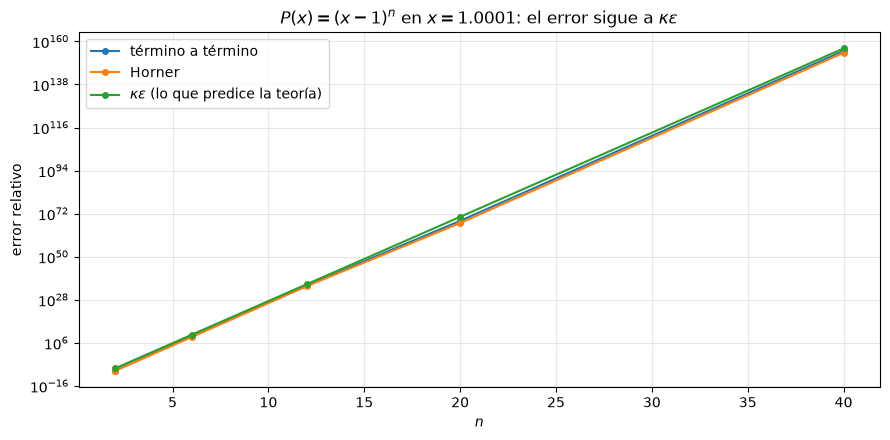

In [11]:
#@title 📈 B2 · La misma medición, ahora como gráfica
#
# La tabla da los números; la gráfica da la relación. En escala logarítmica, si
# el error de cada método sigue a kappa*epsilon, las tres series quedan casi
# pegadas. Eso es lo que hay que mirar: no que el error sea enorme, sino que
# quien manda es la CONDICIÓN de la evaluación, no el método.
#
# Aquí ningún error vale cero, así que no se pierde ningún punto (en escala
# logarítmica un cero no se puede dibujar: no hay logaritmo de cero).
EPS = np.finfo(float).eps
x2 = 1 + 1e-4
grados = [2, 6, 12, 20, 40]
err_ingenuo, err_horner, predicho = [], [], []
for n in grados:
    a2 = coeficientes_binomio(n)
    ex2 = evaluar_exacto(a2, x2)
    v1, _ = evaluar_ingenuo(a2, x2)
    v2 = horner_referencia(a2, x2)[0]
    err_ingenuo.append(error_relativo(v1, ex2))
    err_horner.append(error_relativo(v2, ex2))
    predicho.append(condicion_evaluacion(a2, x2) * EPS)

graficar_errores(
    grados,
    {"término a término": err_ingenuo,
     "Horner": err_horner,
     r"$\kappa\varepsilon$ (lo que predice la teoría)": predicho},
    titulo=r"$P(x)=(x-1)^n$ en $x=1.0001$: el error sigue a $\kappa\varepsilon$",
    etiqueta_x="$n$")


### Cómo se lee la tabla (B2)

El **número de condición** mide cuánto amplifica la evaluación cualquier error de
redondeo:

$$\kappa = \frac{\sum_i \left|a_i\,x^{\,n-i}\right|}{\left|P(x)\right|}
\qquad\Longrightarrow\qquad
\frac{\left|\text{error}\right|}{\left|P(x)\right|} \;\approx\; \kappa\,\varepsilon$$

Si $\kappa = 10^{12}$, la evaluación **pierde 12 dígitos** de los 16 que tiene un
`float`: de nada sirve entonces discutir el último. Fíjate en que la última
columna ($\kappa\varepsilon$) **predice** el error de las dos anteriores y acierta
en el orden de magnitud.

Con $(x-1)^n$ en $x = 1.0001$ pasa lo peor posible:

$$P(x)=\sum_{k=0}^{n}\binom{n}{k}x^{\,n-k}(-1)^k=(x-1)^n=10^{-4n}$$

Los términos $\binom{n}{k}x^{n-k}$ son enormes y alternan de signo, mientras el
resultado es diminuto: al restarlos se cancelan **y con ellos se van los dígitos**.

> **Moraleja.** Con $\kappa$ enorme **ningún** reordenamiento recupera la
> información: se perdió al restar. Horner sale unas pocas veces mejor (no
> arrastra el error de la cadena que calcula $x^k$), pero no hace milagros. Eso no
> es el algoritmo, es la **condición del problema**. Lo que Horner garantiza
> siempre es el costo.


In [ ]:
#@title 🧪 Laboratorio B3 · Un polinomio grande "normal" (sin cancelación)
#
# Coeficientes positivos: todos los términos se suman y ninguno se cancela, así
# que la evaluación está bien condicionada (kappa = 1) y lo único que cambia
# entre los dos métodos es el costo.
#
# Los valores de los dos métodos van con las 17 cifras de un float (el formato
# 'ciencia16' de la columna), y al lado el error relativo de cada uno contra el
# valor exacto.
filas = []
for n in (50, 100, 200, 400):
    a3 = [1.0] * (n + 1)
    x3 = 1.5
    ex3 = evaluar_exacto(a3, x3)
    v1, _ = evaluar_ingenuo(a3, x3)
    v2 = horner_referencia(a3, x3)[0]
    filas.append([n, condicion_evaluacion(a3, x3), v1, error_relativo(v1, ex3),
                  v2, error_relativo(v2, ex3)])

tabla_experimento(
    [('Grado', 'c', 'entero'),
     ('$\\kappa$', 'c', 'num2'),
     ('Término a término', 'c', 'ciencia16'),
     ('Error rel.', 'c', 'ciencia2'),
     ('Horner', 'c', 'ciencia16'),
     ('Error rel.', 'c', 'ciencia2')],
    filas,
    titulo='Evaluado en $x = 1.5$, con todos los coeficientes iguales a 1:')


### Conclusión del laboratorio B

* Con $\kappa = 1$ (la tabla de B3) los dos métodos aciertan con un error del orden
  de $\varepsilon$: la ventaja de Horner vuelve a ser **solo de costo** (20 100
  multiplicaciones contra 200 con $n=200$).
* Con $\kappa$ enorme los dos fallan **parecido**: no hay rescate posible.
* En resumen: **Horner suele salir igual o algo mejor**, pero por factores
  pequeños y sin garantía; la diferencia grande (de dígitos, no de factores) no
  viene del método, sino de la **condición del polinomio en ese punto**.
* Y todo esto se mide con la misma regla: el valor exacto, calculado sin redondear
  nada.


---
# 2 · El algoritmo anidado y lo que te regala

## La recurrencia

Con los coeficientes $a=[a_n, a_{n-1}, \dots, a_0]$ y el punto $x_0$, la
primera corrida es

$$b_n = a_n, \qquad b_k = a_k + b_{k+1}\,x_0 \quad (k = n-1, n-2, \dots, 0)$$

y al terminar:

* **el valor**: $P(x_0) = b_0$;
* **los demás $b$**: los coeficientes del cociente $Q(x)$ de dividir $P(x)$
  entre $(x - x_0)$, es decir

$$P(x) = (x - x_0)\,Q(x) + b_0$$

Ojo con el orden: si tus coeficientes van de mayor a menor grado, al recorrerlos
en ese mismo orden vas obteniendo $b_n, b_{n-1}, \dots, b_0$. El **último** es el
valor del polinomio y **los anteriores** forman $Q$ (sin ese último).

## La derivada, con una segunda corrida

Para la derivada no hace falta derivar el polinomio a mano: se **repite la misma
división sintética**, ahora sobre los $b_k$:

$$c_n = b_n, \qquad c_k = b_k + c_{k+1}\,x_0 \quad (k = n-1, \dots, 1)$$

y el resultado es

$$\boxed{\ P\,'(x_0) = c_1\ }$$

es decir el **penúltimo** valor de esa segunda fila.

## La deflación

Si además $x_0$ resulta ser una **raíz exacta** ($P(x_0)=0$), entonces
$b_0 = 0$ y el cociente cumple

$$P(x) = (x - r)\,Q(x)$$

Eso es **deflactar**: bajar el grado en 1 sin volver a resolver el problema
completo. Es la forma estándar de encontrar *todas* las raíces de un polinomio
(paso a paso, quitando la que ya conoces).

> **Cuidado con dos detalles:** el cociente **conserva el coeficiente líder**
> (si $P$ empieza con $4x^3$, $Q$ empieza con $4x^2$), y si el residuo $b_0$
> **no** es cero, es que $r$ no era raíz exacta: ese residuo vale $P(r)$.

### Las dos filas de la tabla, de un vistazo

El laboratorio de abajo imprime la tabla completa de una división sintética
(la misma que vas a llenar a mano) para que veas de dónde sale cada número.

In [ ]:
#@title 🔬 Laboratorio · la división sintética paso a paso
# Un polinomio de ejemplo cualquiera (NO es el tuyo).
a_demo = [2, -6, 2, -1]
x_demo = 3.0


def division_sintetica_detallada(a, x0):
    '''Imprime cada paso de la primera corrida.'''
    print("Coeficientes a = %s   y   x0 = %g\n" % (a, x0))
    print("Primera corrida (b):")
    b = [float(a[0])]
    print("   b_%d = a_%d = %g" % (len(a) - 1, len(a) - 1, b[0]))
    for k in range(1, len(a)):
        b.append(a[k] + b[k - 1] * x0)
        print("   b_%d = a_%d + b_%d*x0 = %g + %g*%g = %g"
              % (len(a) - 1 - k, len(a) - 1 - k, len(a) - k, a[k], b[k - 1], x0, b[k]))
    print("\n   P(x0) = b_0 = %g" % b[-1])
    print("   Q(x)  = %s" % b[:-1])

    print("\nSegunda corrida (c), sobre los b:")
    c = [b[0]]
    for k in range(1, len(b) - 1):
        c.append(b[k] + c[k - 1] * x0)
        print("   c_%d = b_%d + c_%d*x0 = %g + %g*%g = %g"
              % (len(b) - 1 - k, len(b) - 1 - k, len(b) - k, b[k], c[k - 1], x0, c[k]))
    print("\n   P'(x0) = c_1 = %g" % c[-1])

    # Comprobación: P(x) = (x - x0) Q(x) + P(x0)
    def evaluar(coefs, x):
        n = len(coefs) - 1
        return sum(c * x ** (n - i) for i, c in enumerate(coefs))

    xt = x0 + 1.0
    izq = evaluar(a, xt)
    der = (xt - x0) * evaluar(b[:-1], xt) + b[-1]
    print("\nComprobación en x = %g:  P(x) = %.6f   (x-x0)*Q(x)+b_0 = %.6f"
          % (xt, izq, der))
    return b, c


division_sintetica_detallada(a_demo, x_demo)
print("\nFíjate en que NO aparece ninguna potencia de x elevada: la gracia es")
print("que cada b se calcula con el b anterior.")

---

### ✏️ Pregunta 1

In [ ]:
#@title 🧪 Pregunta 1 · cuánto ahorra la forma anidada
MI_TAREA = generar_tarea(alumno_id)   # tu tarea queda guardada en MI_TAREA
pregunta(1)

---
# 3 · Actividad a mano · Horner: $P(x_0)$ y $P\,'(x_0)$

Aquí abajo está **tu** polinomio (el tuyo, no el de tu compañero) y el punto de
evaluación. Vas a llenar la tabla **a mano, con calculadora**, en este orden:

1. **Fila $b_k$** (primera corrida): empieza con $b = a_n$ y aplica
   $b \leftarrow b \cdot x_0 + a_k$ recorriendo los coeficientes de mayor a menor
   grado. El **último** valor que obtengas es $P(x_0)$.
2. **Fila $c_k$** (segunda corrida): repite lo mismo **pero sobre los $b$** (no
   sobre los $a$). El **penúltimo** valor de esta fila es $P\,'(x_0)$.

Después reporta tus dos resultados en la celda que sigue. **No redondees los
pasos intermedios**: el error se acumula y la comprobación te lo va a decir.

In [ ]:
#@title ✏️✅ Horner · actividad a mano, práctica y preguntas
EJ_HR = mano_enunciado('HORNER')

In [ ]:
# ---------------------------------------------------------------------
#  TU ECUACION, escrita por ti como funciones lambda.
#  P  -> el polinomio del enunciado
#  dP -> su derivada analitica (la que obtendrias derivando a mano)
#
#  Por ejemplo:  P  = lambda x: x**3 - 4*x**2 + 7*x + 1
#                dP = lambda x: 3*x**2 - 8*x + 7
# ---------------------------------------------------------------------
P = None          # <-- escribe TU polinomio   (P = lambda x: ...)
dP = None         # <-- escribe TU derivada    (dP = lambda x: ...)

mano_ecuacion('HORNER', f=P, df=dP)

In [ ]:
# ---------------------------------------------------------------------
#  Escribe aqui tus DOS valores calculados a mano y vuelve a ejecutar
#  esta celda para recibir la realimentacion.
# ---------------------------------------------------------------------
MIS_HR = [0.0, 0.0]          # <-- [P(x_0), P'(x_0)]

mano_comprueba('HORNER', MIS_HR)

---
### 💻 Pregunta 2 · programa el algoritmo

Ahora vas a programar exactamente lo que acabas de hacer a mano, pero para
cualquier polinomio. La pregunta pide una función con esta firma:

```python
horner(a, x0)  ->  (p_val, dp_val, Q)
```

* `a` es la lista de coeficientes **de mayor a menor grado**;
* devuelve el valor, la derivada y la **lista** del cociente.

Se califica con **casos ocultos** (polinomios que nunca ves), así que no sirve
devolver un número fijo ni llamar a `numpy.polyval`: hay que recorrer los
coeficientes con la recurrencia.

In [ ]:
#@title Pregunta 2 · programar horner con casos ocultos
pregunta(2)

In [ ]:
# --- Práctica: programa el método ------------------------------------
def horner(a, x0):
    '''
    Forma anidada de Horner.

    Parametros
    ----------
    a  : lista de coeficientes de MAYOR a menor grado, [a_n, ..., a_0]
    x0 : punto de evaluacion

    Devuelve
    --------
    (p_val, dp_val, Q)
        p_val  : P(x0)
        dp_val : P'(x0)
        Q      : lista de los coeficientes del cociente P(x)/(x - x0),
                 tambien de mayor a menor grado
    '''
    # =================================================================
    #  ESCRIBE TU CODIGO AQUI
    #  Primera corrida:  b = a[0]; para cada coeficiente siguiente
    #      b = b*x0 + a_k        (ve guardando cada b)
    #  Segunda corrida:  igual, pero sobre los b_k ya guardados
    #      (el resultado P'(x0) es el PENULTIMO de esa fila)
    #  Y ojo: Q son los b SIN el ultimo.
    # =================================================================
    # return (p_val, dp_val, Q)
    raise NotImplementedError("Completa la funcion horner") # Borra esta línea


# --- Prueba con TU ejercicio -----------------------------------------
try:
    _p, _d, _q = horner(EJ_HR['a'], EJ_HR['x0'])
    comparar_practica('HORNER', EJ_HR, (_p, _d, _q))
except NotImplementedError as exc:
    print("Todavia no terminas la funcion:", exc)
except TypeError as exc:
    print("Tu funcion devolvio algo que no se puede leer:", exc)

# --- Solución de referencia (revisa DESPUES de intentarlo) -----------
tabla('HORNER', EJ_HR)

---
### ✏️ Preguntas 3 y 4 · los dos valores de tu ejercicio

Ya tienes la tabla llena a mano y la función programada. Contesta con los
números de **tu** ejercicio (los mismos que reportaste en `MIS_HR`). Si quieres
comprobar antes, ejecuta `mano_solucion('HORNER')`.

In [ ]:
pregunta(3)      # el valor P(x_0)

In [ ]:
pregunta(4)      # la derivada P'(x_0)

---
# 4 · Deflación: quitar una raíz que ya conoces

Cuando ya sabes que $r$ es raíz de $P$, dividir entre $(x-r)$ te deja un
polinomio de un grado menos **con las mismas raíces restantes**:

$$P(x) = (x - r)\,Q(x) + \underbrace{P(r)}_{b_0}$$

Esa división es **exactamente la primera corrida de Horner evaluada en $r$**, así
que no hay que programar nada nuevo: los coeficientes de $Q$ son los $b_k$ que
obtuviste, sin el último.

## ¿Para qué sirve?

Encontrar todas las raíces de un polinomio de grado alto es un problema difícil.
La estrategia estándar es:

1. encuentra **una** raíz (con Newton, Bairstow, Müller… o «por inspección»);
2. **deflacta** para bajar el grado;
3. repite con el polinomio reducido.

Y si el residuo no sale cero, es que la raíz era solo **aproximada**: ese residuo
es $P(r)$, el error que cometerías al dar por buena esa raíz.

> ⚠️ **El error clásico al deflactar a mano:** dividir como si el polinomio fuera
> mónico. Si $P$ empieza con $4x^3$, entonces $Q$ empieza con $4x^2$: el
> coeficiente líder **se conserva**.

In [ ]:
#@title ✏️✅ Deflación · actividad a mano y pregunta
EJ_DF = mano_enunciado('DEFLACION')

In [ ]:
# ---------------------------------------------------------------------
#  TU ECUACION, escrita por ti como funcion lambda.
#  Es el MISMO polinomio del enunciado (el de arriba).
#
#  Por ejemplo:  P = lambda x: x**3 - 6*x**2 + 7*x + 6
# ---------------------------------------------------------------------
P = None          # <-- escribe TU polinomio   (P = lambda x: ...)

mano_ecuacion('DEFLACION', f=P)

In [ ]:
# ---------------------------------------------------------------------
#  Escribe aqui los TRES coeficientes del polinomio reducido Q(x),
#  de MAYOR a menor grado, y vuelve a ejecutar esta celda.
# ---------------------------------------------------------------------
MIS_DF = [0.0, 0.0, 0.0]          # <-- [A, B, C]

mano_comprueba('DEFLACION', MIS_DF)

In [ ]:
pregunta(5)      # los coeficientes de Q(x)

---
### 🧪 Laboratorio · deflación progresiva hasta agotar las raíces

Tu ejercicio tiene una raíz exacta conocida, así que se puede deflactar **en
serie**: encuentra las raíces del polinomio reducido y ya tienes todas.

Aquí se comparan dos caminos y se comprueba el residuo. Fíjate en la última
parte: cuando la raíz **no** es exacta, el residuo es justo el error.

In [ ]:
#@title 🧪 Laboratorio · deflación progresiva y comparación con numpy.roots
a = [float(c) for c in EJ_DF['a']]
r = float(EJ_DF['x0'])

print("Polinomio a = %s   con la raíz conocida r = %g\n" % (a, r))

# --- 1) Deflactar con la raíz conocida -------------------------------
Q, residuo = deflactar(a, r)
print("Deflación entre (x - %g):" % r)
print("   Q(x)    = %s" % Q)
print("   residuo = %g   %s" % (residuo, "(exacta ✅)" if abs(residuo) < 1e-12
                                 else "(NO era raíz exacta ❌)"))

# --- 2) Todas las raíces, por los dos caminos ------------------------
print("\nRaíces del polinomio reducido Q (con numpy.roots):")
raices_q = raices_de(Q)
for z in sorted(raices_q, key=lambda z: (round(z.real, 6), round(z.imag, 6))):
    print("   %s" % ("%.8f" % z.real if abs(z.imag) < 1e-12 else "%.8f %+.8fj"
                     % (z.real, z.imag)))

print("\nTodas las raíces del polinomio original (numpy.roots directo):")
for z in sorted(raices_de(a), key=lambda z: (round(z.real, 6), round(z.imag, 6))):
    print("   %s" % ("%.8f" % z.real if abs(z.imag) < 1e-12 else "%.8f %+.8fj"
                     % (z.real, z.imag)))
print("\n   (deben coincidir: r más las de Q)")

# --- 3) Comprobacion: P(x) == (x - r)*Q(x) ---------------------------
def evaluar(coefs, x):
    n = len(coefs) - 1
    return sum(c * x ** (n - i) for i, c in enumerate(coefs))

peor = 0.0
for xt in (-2.0, -0.5, 0.0, 1.7, 4.3):
    izq = evaluar(a, xt)
    der = (xt - r) * evaluar(Q, xt) + residuo
    peor = max(peor, abs(izq - der) / max(1.0, abs(izq)))
print("\nComprobación P(x) = (x-r)Q(x) + residuo en 5 puntos: peor diferencia %.2e" % peor)

# --- 4) ¿Y si la raíz NO fuera exacta? -------------------------------
r_mal = r + 0.05
Q_mal, res_mal = deflactar(a, r_mal)
print("\nSi en lugar de r = %g usas r = %g (0.05 de error):" % (r, r_mal))
print("   residuo = %+.6f   <- esto vale P(%.2f), el error de suponerla raíz"
      % (res_mal, r_mal))
print("   P(%.2f) = %+.6f   (comprueba que coincide)" % (r_mal, evaluar(a, r_mal)))

---
# 5 · Conclusiones

## Lo que hay que llevarse

1. **La forma anidada baja el costo de $O(n^2)$ a $O(n)$** porque cada paso
   reutiliza el resultado del anterior.
2. **Una sola corrida da tres cosas**: el valor, el polinomio deflactado y —con
   una segunda corrida— la derivada. Es el «dos por uno» que hace que Newton y
   Bairstow evalúen derivadas gratis.
3. **Deflactar es dividir entre $(x-r)$**: baja el grado y conserva las raíces
   que faltan. Si el residuo no es cero, $r$ no era raíz exacta y ese residuo
   mide el error.
4. **El coeficiente líder se conserva** al deflactar. Es el error más común a
   mano.
5. **El costo baja siempre** ($O(n)$ en lugar de $O(n^2)$), que es exactamente lo
   que necesita un microcontrolador evaluando una calibración. El **error** es
   otra historia: Horner suele salir igual o algo mejor, pero quien decide
   cuántos dígitos se pierden es la **condición** de la evaluación ($\kappa$), no
   el método. Hay que medirlo, no suponerlo.

## Autoevaluación rápida

* ¿Por qué $n$ multiplicaciones y no $\frac{n(n+1)}{2}$?
* ¿De dónde sale el $Q(x)$ de la primera corrida, si nunca dividiste nada?
* ¿Por qué $P\,'(x_0)$ es el **penúltimo** valor de la segunda corrida y no el
  último?
* Si al deflactar el residuo te da $-0.37$, ¿qué significa ese número?
* ¿Por qué no basta con evaluar el polinomio término a término si el resultado
  «sale bien»?

---

### ✏️ Pregunta 6


In [ ]:
#@title 🧪 Pregunta 6 · decisión de ingeniería
pregunta(6)

---
# 6 · Entrega

## Antes de enviar

1. **Revisa tus 6 preguntas.** Si alguna está en blanco el sistema la cuenta
   como error.
2. **Completa la función `horner`.** Se prueba con polinomios que nunca ves.
3. **Imprime la hoja de trabajo manual** (celda de abajo). Va junto con tu
   cuaderno: ahí aparecen tus dos tablas a mano con los valores que reportaste y
   los de referencia, para que tu profesor califique rápido las 2 rúbricas (30 %
   de la calificación).
4. Necesitas **$\ge 90\%$** de los 100 puntos automáticos para poder enviar. Si
   no llegas, corrige y vuelve a ejecutar.

| Sección | Actividad a mano | ¿La reportaste? |
|---|---|---|
| 3 | Horner: $P(x_0)$ y $P\,'(x_0)$ | `MIS_HR` |
| 4 | Deflación: coeficientes de $Q(x)$ | `MIS_DF` |

> Si te quedó alguna pregunta mal, **no** borres tu trabajo: primero entiende
> **por qué** falló. Los errores de esta tarea son exactamente los que aparecen
> en el examen final (y en la siguiente entrega, donde Müller y Bairstow usan
> estas mismas divisiones sintéticas).

In [ ]:
#@title 📋 Hoja de trabajo manual (entrégala con tu cuaderno)
hoja_manual()

In [ ]:
#@title 📤 Calificar y enviar
enviar(alumno_id)